<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
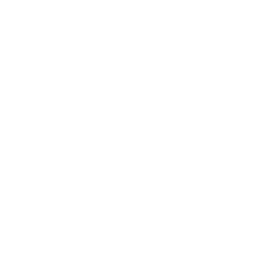
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Identifikation af markedsregimer</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Kvantitativ finansiering / Kapitalforvaltning &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Sammenfatning

Dette eksempel bruger **PROC ACECLUS** til at finde den latente struktur, der adskiller markedsregimer, og klynger derefter på den. Ud fra 100 ugentlige observationer af 10 markedsfeatures (aktieafkast og volatilitet, kredit- og high-yield-spænd, 2-årig/10-årig kurven, dollaren, råvarer og en VIX-ændring) estimerer ACECLUS en tilnærmet inden-for-regime-kovarians *uden* at bruge nogen regimeetiket og udleder kanoniske variable, langs hvilke regimerne trækker fra hinanden.

Ved P=0.02-tærsklen konvergerer algoritmen i to iterationer og beholder **tre kanoniske dimensioner**, som tilsammen forklarer hele spredningen mellem regimer (egenværdiandele 57,8 %, 24,4 %, 17,8 %). En løsere P=0.05-tærskel udglatter kovariansen for meget og **kollapser strukturen til en enkelt dimension** — en nyttig påmindelse om, at tærsklen i væsentlig grad former resultatet.

Ved at føre de tre kanoniske variable ind i **PROC FASTCLUS** (k=4) opnås en ren ordning af de 100 uger efter stressgrad (samlet R² = 0,51, pseudo-F = 33,2): en 62-ugers rolig kerne, en 22-ugers gruppe under bedring/aftagende volatilitet, en 12-ugers gruppe med forhøjet stress og en 4-ugers gruppe med dyb krise, hvor high-yield-spændene i gennemsnit ligger på ~1.514 bps. Disse tildelinger eksporteres til efterfølgende betingning af porteføljerisiko.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Ugentlige observationer af markedsfeatures på tværs af aktivklasser | 100 |
| Variable: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

Serien genereres af en Markov-regimeskiftende proces med fem tilstande (bull-ekspansion, sen cyklus, risk-off, krise, bedring) med regimebetingede feature-fordelinger. Kørt ulicenseret er feature-tabellen begrænset til de første 100 ugentlige observationer (~2 år) — et bull-domineret vindue, der også besøger en kort krise og en bedring. Ugentlige afkast og niveauændringer træder i stedet for ugeafsluttende prisbevægelser; spænd er i basispoint, og volatilitet er et VIX-lignende indeks.

---

In [1]:
/* --------------------------------------------------------
   Generér en ugentlig multi-aktiv-markedshistorik med fem
   indlejrede regimetilstande drevet af en Markov-skifte-
   proces. Dette eksempel kører ulicenseret, så feature-
   tabellen nedenfor er begrænset til de første 100 ugentlige
   observationer (~2 år) -- et tyredomineret vindue afbrudt
   af en kort krise og et opsving.
   -------------------------------------------------------- */
data work.market_weekly;
    CALL streaminit(42);
    /* 5 regimer: 1=Tyremarked, 2=Sencyklus, 3=Risikoflugt, 4=Krise, 5=Genopretning */
    TABEL regime_names[5] $16 _temporary_
        ('Tyremarked' 'Sencyklus' 'Risikoflugt'
         'Krise' 'Genopretning');
    BEHOLD_VÆRDI current_regime 1;
    GØR week_id = 1 TIL 5000;
        /* Markov-regimeskifte */
        u = rand('uniform');
        HVIS current_regime = 1 SÅ GØR; /* Tyremarked: langlivet */
            HVIS u > 0.97 SÅ current_regime = 2;
        SLUT;
        ELLERS HVIS current_regime = 2 SÅ GØR; /* Sencyklus */
            HVIS u > 0.92 SÅ current_regime = 3;
        SLUT;
        ELLERS HVIS current_regime = 3 SÅ GØR; /* Risikoflugt */
            HVIS u > 0.80 SÅ current_regime = 4;
            ELLERS HVIS u < 0.10 SÅ current_regime = 1;
        SLUT;
        ELLERS HVIS current_regime = 4 SÅ GØR; /* Krise: kort */
            HVIS u > 0.75 SÅ current_regime = 5;
        SLUT;
        ELLERS HVIS current_regime = 5 SÅ GØR; /* Genopretning */
            HVIS u > 0.85 SÅ current_regime = 1;
        SLUT;
        regime_label = regime_names[current_regime];
        /* Regimebetingede feature-fordelinger */
        HVIS current_regime = 1 SÅ GØR;  /* Tyremarked */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        SLUT;
        ELLERS HVIS current_regime = 2 SÅ GØR;  /* Sencyklus */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        SLUT;
        ELLERS HVIS current_regime = 3 SÅ GØR;  /* Risikoflugt */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        SLUT;
        ELLERS HVIS current_regime = 4 SÅ GØR;  /* Krise */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        SLUT;
        ELLERS GØR;  /* Genopretning */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        SLUT;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        HVIS week_id = 1 SÅ vix_chg = 0;
        UDDATA;
    SLUT;
    FJERN u;
    OMDØB credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
KØR;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.40 seconds
  cpu   1.40 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline-markedsfeature-fordelinger pr. regime
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.market_weekly n mean std MIN MAX;
    KLASSE regime_label;
    VARIABEL eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    MÆRKAT eq_return_pct="Aktieafkast (%)"
           eq_vol_idx="Aktievolatilitetsindeks"
           credit_spread_bps="Kreditspænd (bp)"
           hy_spread_bps="High-yield-spænd (bp)"
           term_spread="Terminsspænd"
           vix_chg="VIX-ændring"
           regime_label="Markedsregime";
KØR;

                                                  The MEANS Procedure

                                   Analysis Variable : eq_return_pct Aktieafkast (%)

        Markedsregime          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------
        Genopretning               4      0.0077500      1.5951747     -0.8330000      2.4000000
        Krise                     12     -2.3403333      3.9436692     -8.0160000      3.7360000
        Risikoflugt               17     -0.8447059      1.2832441     -3.3850000      1.1810000
        Sencyklus                 39      0.0364359      1.9733801     -4.6010000      3.7030000
        Tyremarked                28      0.2860000      1.0226518     -1.5980000      2.2150000
        ----------------------------------------------------------------------------------------

                                 Analysis Variable : eq_vol_idx Ak


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


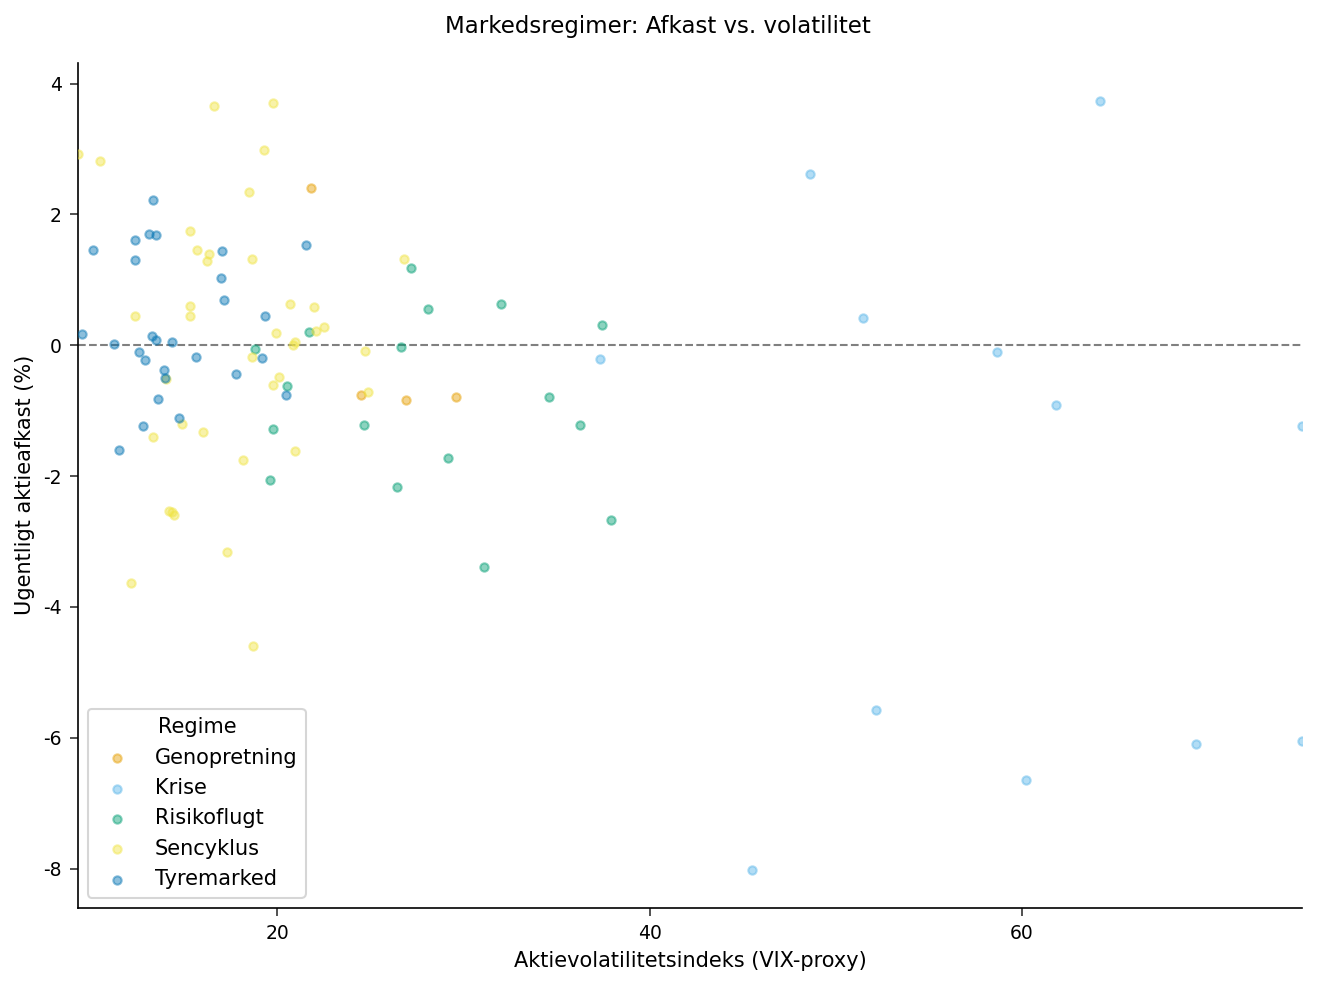

In [3]:
/* --------------------------------------------------------
   Aktieafkast vs. volatilitetsindeks pr. regimelabel
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS MÆRKAT="Aktievolatilitetsindeks (VIX-proxy)";
    YAXIS MÆRKAT="Ugentligt aktieafkast (%)";
    keylegend / TITEL="Regime";
    TITEL "Markedsregimer: Afkast vs. volatilitet";
KØR;

---

In [4]:
/* --------------------------------------------------------
   Approksimeret estimation af kovarians inden for regime.
   ACECLUS estimerer den poolede kovarians inden for klynger
   uden at kende klyngelabels og udleder derefter kanoniske
   variable, der adskiller regimerne. P=0.02 sætter
   tærsklen for parvis afstand: kun de nærmeste ~2% af
   observationspar behandles som samme regime.
   -------------------------------------------------------- */
PROCEDURE aceclus data=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    VARIABEL eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
KØR;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Følsomhedstjek ved P=0.05 -- en løsere tærskel for samme
   regime trækker flere par ind og oppuster den estimerede
   kovarians inden for regime. Sammenlign den kanoniske
   struktur (egenværdier og bevarede dimensioner) med
   P=0.02-løsningen.
   -------------------------------------------------------- */
PROCEDURE aceclus data=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    VARIABEL eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
KØR;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-means på de kanoniske ACECLUS-variable. ACECLUS
   bevarede tre kanoniske dimensioner (Can1-Can3), så
   klyngeinddelingen kører på dem. Fire klynger sigter mod
   de fire velbefolkede markedstilstande.
   -------------------------------------------------------- */
PROCEDURE FASTCLUS data=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    VARIABEL can1 can2 can3;
KØR;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4                   4         1.7742             4.0619              2         4.1923

                                    


NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                         Regimeklynge vs. faktisk markedsregime                                         

                                                   The FREQ Procedure

Table of Klynge by Markedsregime

Klynge |Genopretning |       Krise | Risikoflugt |   Sencyklus |  Tyremarked |        Total
-------+-------------+-------------+-------------+-------------+-------------+-------------
1      |           0 |           4 |           4 |           2 |           2 |           12
       |        0.00 |        4.00 |        4.00 |        2.00 |        2.00 |        12.00
-------+-------------+-------------+-------------+-------------+-------------+-------------
2      |           3 |           3 |           7 |          28 |          21 |           62
       |        3.00 |        3.00 |        7.00 |       28.00 |       21.00 |        62.00
-------+-------------+-------------+-------------+-------------+-------------+-------------
3      |           1 |           2 | 


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


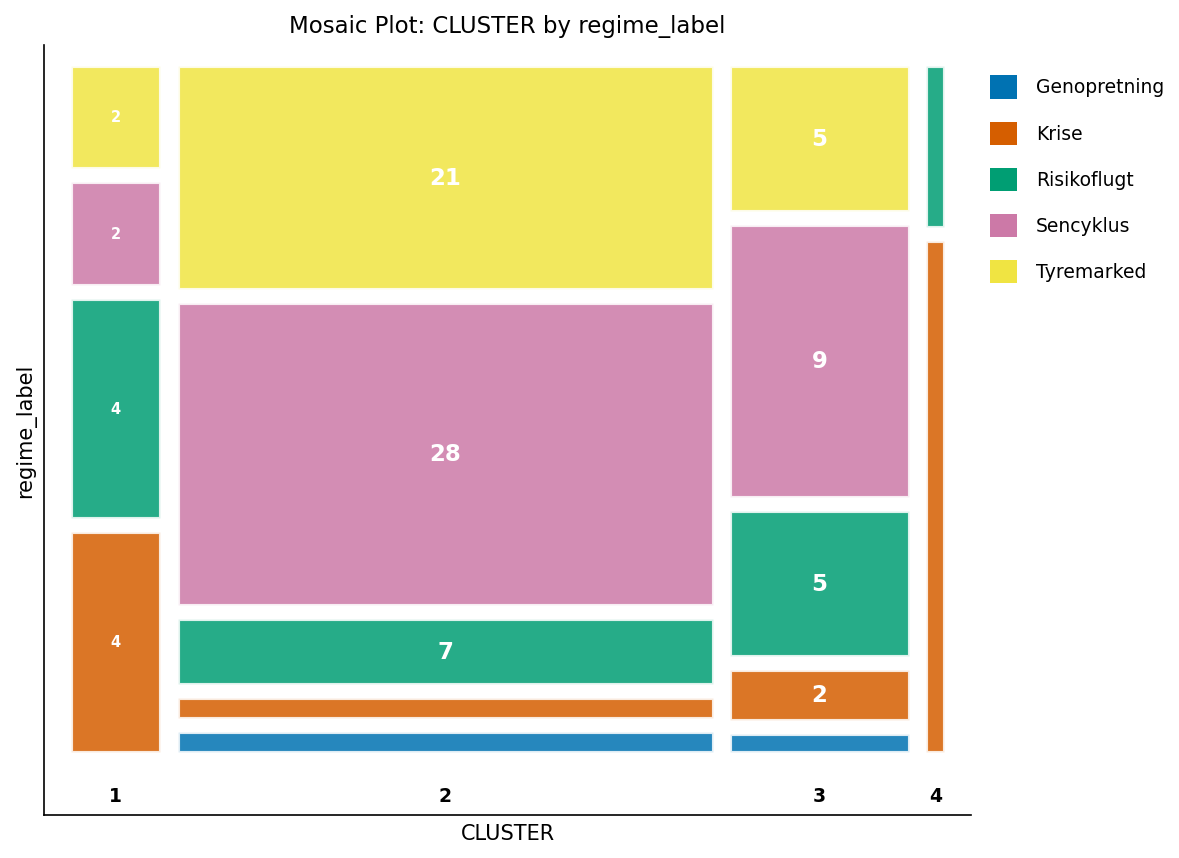

In [7]:
/* --------------------------------------------------------
   Validér tildelte klynger mod kendte
   regimelabels fra datagenereringen
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    MÆRKAT CLUSTER="Klynge" regime_label="Markedsregime";
    TITEL "Regimeklynge vs. faktisk markedsregime";
KØR;

In [8]:
/* --------------------------------------------------------
   Profilér regime-feature-gennemsnit til fortolkning
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.regime_assignments mean;
    KLASSE CLUSTER;
    VARIABEL eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    MÆRKAT eq_return_pct="Aktieafkast (%)"
           eq_vol_idx="Aktievolatilitetsindeks"
           credit_spread_bps="Kreditspænd (bp)"
           hy_spread_bps="High-yield-spænd (bp)"
           term_spread="Terminsspænd"
           vix_chg="VIX-ændring"
           CLUSTER="Klynge";
KØR;

                                         Regimeklynge vs. faktisk markedsregime                                         

                                                  The MEANS Procedure

                                             Analysis Variable : eq_return_pct Aktieafkast (%)

                                                         N
                                             Klynge    Obs            Mean
                                             -----------------------------
                                             1          12      -2.0955000
                                             2          62      -0.3638871
                                             3          22       0.7421364
                                             4           4      -0.4010000
                                             -----------------------------

                                             Analysis Variable : eq_vol_idx Aktievolatilitetsindeks

                         


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Fortolkning

**ACECLUS kanonisk struktur.** På stikprøven af 100 uger konvergerede PROC ACECLUS (P=0.02, tærskel = 2.578941) i to iterationer og producerede tre kanoniske variable. Deres egenværdier af `Inv(ACE)*(COV-ACE)` er 0,0219, 0,0093 og 0,0067, dvs. andele på 57,8 %, 24,4 % og 17,8 % (kumulativt 100 %). Den første kanoniske akse bærer den dominerende risk-on/risk-off-kontrast; den anden og tredje forfiner den. Fordi aktievolatilitets- og spændfeatures samvarierer stærkt, folder ACECLUS den fælles variation ind i inden-for-regime-kovariansen, så de kanoniske akser afspejler ægte adskillelse mellem regimer snarere end fælles skala.

**Tærskelfølsomhed.** Ny kørsel ved P=0.05 hæver afstandstærsklen til 2.899704, hvilket trækker 4.949 af de 4.950 observationspar inden for grænsen. Den estimerede inden-for-regime-kovarians bliver da næsten lig med den samlede kovarians, og den kanoniske struktur **kollapser til en enkelt dimension** (én egenværdi, 0,0096, ved 100 %). P=0.02- og P=0.05-løsningerne er derfor *ikke* udskiftelige her — en løsere tærskel udvisker de finere regimeakser, så den strammere tærskel er den mere informative specifikation for denne stikprøve.

**Klyngedannelse på de kanoniske variable.** PROC FASTCLUS (k=4) på Can1–Can3 giver et samlet R² på 0,5089 og et pseudo-F på 33,16. Can2 udfører det meste af adskillelsesarbejdet (R² = 0,626), Can1 bidrager moderat (R² = 0,359), og Can3 tilføjer i det væsentlige intet (R² = 0,000) — i overensstemmelse med, at kun to akser bærer et stærkt signal. De fire klynger stiller sig op som en markedsstressgradient:

| Klynge | n | Gns. aktieafkast | Gns. VIX | Gns. HY-spænd | Gns. VIX-ændring | Læsning |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0,36 % | 20,4 | 534 bps | +1,2 | Rolig kerne (bull / sen cyklus) |
| 3 | 22 | +0,74 % | 20,5 | 539 bps | -9,6 | Under bedring, faldende volatilitet |
| 1 | 12 | -2,10 % | 39,0 | 720 bps | +11,3 | Forhøjet stress, volatilitet stiger kraftigt |
| 4 |  4 | -0,40 % | 47,4 | 1.514 bps | +0,1 | Dyb krise, ekstrem kreditstress |

**Klynge vs. sandt regime.** Krydstabellen viser, at klyngerne ikke afbilder én-til-én på de fem genererende etiketter — som forventet, fordi etiketterne overlapper kraftigt i feature-rummet ved denne stikprøvestørrelse. Den store rolige klynge (62) optager de fleste bull- (21) og sen-cyklus- (28) uger; den dybe kriseklynge (4) er næsten udelukkende de mest ekstreme kriseuger (3 af 4). De kanoniske akser organiserer således ugerne efter *sværhedsgrad*, ikke efter nøjagtig etiket, hvilket er det mere handlingsrettede signal til risikobetingning.

**Anvendelse.** De eksporterede ugentlige tildelinger understøtter taktisk betingning: reducér risiko og forlæng varigheden, efterhånden som uger vandrer mod klynge 1 og 4, og genoptag risiko, når de vender tilbage til den rolige kerne (klynge 2) eller bedringsgruppen (klynge 3).

---

In [9]:
/* --------------------------------------------------------
   Eksportér ugentlige regimetildelinger til betingning af
   porteføljerisikomodellen og signalgenerering
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>